In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def khoitao_psi0(x):
    global sigma_0, k_0, x_0
    psi_0 = np.exp(-1/2 * ((x-x_0)/sigma_0)**2 )*np.exp(1j*k_0*x) * (np.pi*sigma_0**2)**(-1/4)
    return psi_0

def thenang(x):
    global V_max
    if 0 <= x <= 15:
        V = 0
    else:
        V = V_max
    return V

def khoitao_x_t(x_min, x_max, t_min, t_max, dx, dt):
    N_x = int(round((x_max - x_min) / dx)) + 1
    N_t = int(round((t_max - t_min) / dt)) + 1
    x = np.linspace(x_min, x_max, N_x)
    t = np.linspace(t_min, t_max, N_t)
    return x, t, N_x, N_t

def kiemtra_CFL(dt, dx, V_max):
    dieu_kien = 1 / (2 / dx**2 + V_max)
    if dt <= dieu_kien:
        print("Dieu kien CFL duoc thoa man.")
        return True
    else:
        print("Khong the hoi tu do vi pham dieu kien CFL.")
        return False


In [22]:
def khoitao_matran_g_frog_2():
    global N_x, N_t, x_min, dx, dt, hbar, m
    g = np.zeros(N_x, dtype=complex)
    for i in range(N_x):
        x_i = x_min + i*dx
        V = thenang(x_i)
        g[i] = -2j*dt/hbar * (hbar**2/(m*dx**2)+ V) #phu thuoc vao x
    a = 1j*hbar*dt/(m*dx**2)
    return g, a

In [23]:
def giai_leapfrog_bac2():
    global x_min, x_max, t_min, t_max, dx, dt, x, t, N_x, N_t
    psi_t_x = np.zeros([N_t,N_x], dtype=np.complex128)
    psi_0 = khoitao_psi0(x)

    g, a = khoitao_matran_g_frog_2()

    psi_t_x[0] = psi_0

    for j in range(1, N_x-1):
        psi_t_x[1,j] = psi_t_x[0,j] + 0.5*g[j]*psi_t_x[0,j] + 0.5*a*(psi_t_x[0,j+1]+psi_t_x[0,j-1])

    for n in range(1,N_t-1):
        for j in range(1,N_x-1):
            psi_t_x[n+1,j] = g[j]*psi_t_x[n,j] + a*(psi_t_x[n,j+1]+psi_t_x[n,j-1]) + psi_t_x[n-1,j]

    return psi_t_x

In [24]:
def khoitao_matran_g_frog_4():
    global N_x, N_t, x_min, dx, dt, hbar, m
    g = np.zeros(N_x, dtype=complex)
    for i in range(N_x):
        x_i = x_min + i*dx
        V = thenang(x_i)
        g[i] = -2j*dt/hbar * (5*hbar**2/(4*m*dx**2)+ V) #phu thuoc vao x
    a = 1j*hbar*dt/(12*m*dx**2)
    return g, a

In [25]:
def giai_leapfrog_bac4():
    global x_min, x_max, t_min, t_max, dx, dt, x, t, N_x, N_t
    psi_t_x = np.zeros([N_t,N_x], dtype=np.complex128)
    psi_0 = khoitao_psi0(x)

    g, a = khoitao_matran_g_frog_4()

    psi_t_x[0] = psi_0

    for j in range(2, N_x-2):
        psi_t_x[1,j] = psi_t_x[0,j] + 0.5*g[j]*psi_t_x[0,j] +8*a*(psi_t_x[0,j+1]+psi_t_x[0,j-1]) - 0.5*a*(psi_t_x[0,j+2]+psi_t_x[0,j-2])

    for n in range(1,N_t-1):
        for j in range(2,N_x-2):
            psi_t_x[n+1,j] = g[j]*psi_t_x[n,j] + 16*a*(psi_t_x[n,j+1]+psi_t_x[n,j-1]) - a*(psi_t_x[n,j+2]+psi_t_x[n,j-2])+ psi_t_x[n-1,j]

    return psi_t_x

In [26]:
def luu_ketqua_psi(output_name, x, t, y, save_every_time=1, save_every_x = 1):
    global N_x, N_t, dx, dt, sigma_0, k_0, x_min, x_max, t_min, t_max
    filename = f"TDSE-ketqua-{output_name}.txt"

    with open(filename, "w", encoding="utf-8") as f:
        f.write("# KET QUA GIAI PHUONG TRINH SCHRODINGER PHU THUOC THOI GIAN\n\n")

        f.write("#" * 150 + "\n")
        f.write("# THAM SO DAU VAO\n")
        f.write("#" * 150 + "\n\n")

        f.write(f"# N_x        = {N_x}\n")
        f.write(f"# N_t        = {N_t}\n")
        f.write(f"# x_min      = {x_min}\n")
        f.write(f"# x_max      = {x_max}\n")
        f.write(f"# t_min      = {t_min}\n")
        f.write(f"# t_max      = {t_max}\n")
        f.write(f"# dx         = {dx}\n")
        f.write(f"# dt         = {dt}\n")
        f.write(f"# sigma_0    = {sigma_0}\n")
        f.write(f"# k_0        = {k_0}\n")
        f.write(f"# cach_deu_time = {save_every_time}\n")

        f.write("\n" + "#" * 150 + "\n\n")

        f.write(f"#{'t':>15s} {'x':>15s} {'Re_psi':>15s} {'Im_psi':>15s} {'|psi|':>15s} {'|psi|^2':>15s}\n")

        for n in range(0, len(t), save_every_time):
            for i in range(0, len(x), save_every_x):
                psi = y[n, i]

                f.write(f" {t[n]:>15.6e} "
                        f"{x[i]:>15.6e} "
                        f"{psi.real:>15.6e} "
                        f"{psi.imag:>15.6e} "
                        f"{np.abs(psi):>15.6e} "
                        f"{np.abs(psi)**2:>15.6e}\n")

            f.write("\n")

In [27]:
def luu_file_xac_xuat(output_name, x, t, y, save_every_time=1):
    global N_x, N_t, dx, dt, sigma_0, k_0, x_min, x_max, t_min, t_max
    filename = f"TDSE-ketqua-{output_name}-xacxuat.txt"

    with open(filename, "w", encoding="utf-8") as f:
        f.write("# KET QUA GIAI PHUONG TRINH SCHRODINGER PHU THUOC THOI GIAN\n\n")

        f.write("#" * 150 + "\n")
        f.write("# THAM SO DAU VAO\n")
        f.write("#" * 150 + "\n\n")

        f.write(f"# N_x        = {N_x}\n")
        f.write(f"# N_t        = {N_t}\n")
        f.write(f"# x_min      = {x_min}\n")
        f.write(f"# x_max      = {x_max}\n")
        f.write(f"# t_min      = {t_min}\n")
        f.write(f"# t_max      = {t_max}\n")
        f.write(f"# dx         = {dx}\n")
        f.write(f"# dt         = {dt}\n")
        f.write(f"# sigma_0    = {sigma_0}\n")
        f.write(f"# k_0        = {k_0}\n")
        f.write(f"# cach_deu_time = {save_every_time}\n")

        f.write("\n" + "#" * 150 + "\n\n")

        f.write(f"#{'t':>15s} {'Integral_|psi|^2_dx':>25s}\n")

        for n in range(0, len(t), save_every_time):

            prob_x = np.abs(y[n, :])**2
            tong_xac_xuat = np.trapz(prob_x, x)

            f.write(f" {t[n]:>15.6e} "
                    f"{tong_xac_xuat:>25.6e}\n")

In [28]:
sigma_0 = 0.5
dx = 0.05
dt = 1/4*dx**2
k_0 = 8
x_0 = 5

hbar = 1
m = 1

t_min = 0
t_max = 1.2

x_min = 0
x_max = 15

V_max = 500
kiemtra_CFL(dt, dx, V_max)

x, t, N_x, N_t = khoitao_x_t(x_min, x_max, t_min, t_max, dx, dt)

Dieu kien CFL duoc thoa man.


In [29]:
psi_t_x_bac_2 = giai_leapfrog_bac2()
psi_t_x_bac_4 = giai_leapfrog_bac4()

In [30]:
luu_ketqua_psi("Leapfrog_Bac2", x, t, y=psi_t_x_bac_2, save_every_time=100)
luu_file_xac_xuat("Leapfrog_Bac2", x, t, y=psi_t_x_bac_2, save_every_time=100)

/tmp/ipykernel_76517/1462259009.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  tong_xac_xuat = np.trapz(prob_x, x)


In [31]:
luu_ketqua_psi("Leapfrog_Bac4", x, t, y=psi_t_x_bac_4, save_every_time=100)
luu_file_xac_xuat("Leapfrog_Bac4", x, t, y=psi_t_x_bac_4, save_every_time=100)

/tmp/ipykernel_76517/1462259009.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  tong_xac_xuat = np.trapz(prob_x, x)


In [32]:
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

In [33]:
t_xacsuat_bac2, N_bac2 = np.loadtxt("TDSE-ketqua-Leapfrog_Bac2-xacxuat.txt", unpack = True, comments = "#")
t_xacsuat_bac4, N_bac4 = np.loadtxt("TDSE-ketqua-Leapfrog_Bac4-xacxuat.txt", unpack = True, comments = "#")

x_bac2, t_bac2, psi_bac2 = np.loadtxt("TDSE-ketqua-Leapfrog_Bac2.txt", unpack = True, comments = "#", usecols=(0,1,4))
x_bac4, t_bac4, psi_bac4 = np.loadtxt("TDSE-ketqua-Leapfrog_Bac4.txt", unpack = True, comments = "#", usecols=(0,1,4))

<Figure size 700x600 with 0 Axes>

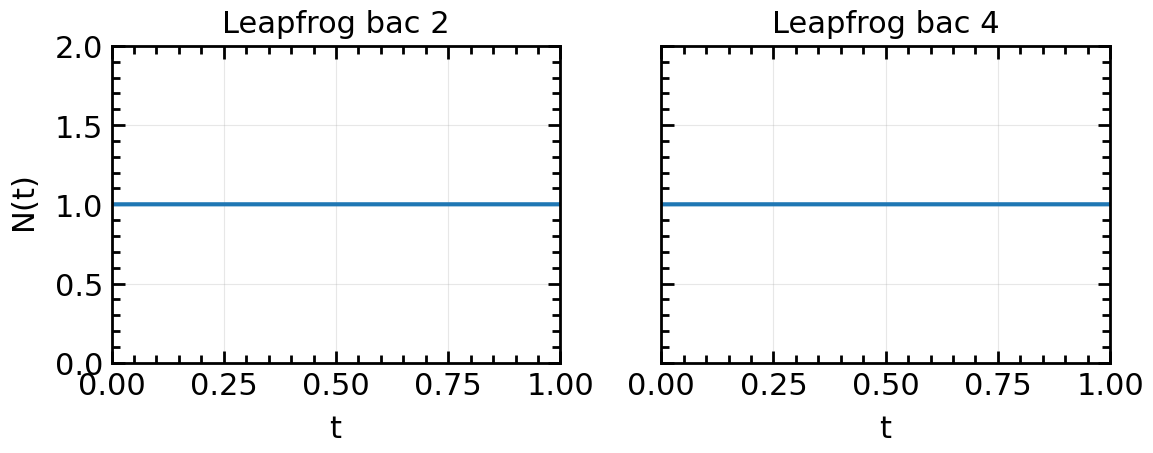

In [34]:
plt.figure(figsize=(7, 6))

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax[0].plot(t_xacsuat_bac2, N_bac2, linewidth = 3)
ax[0].set_xlabel(r"$t$")
ax[0].set_ylabel(r"$N(t)$")
ax[0].set_title("Leapfrog bac 2")
ax[0].grid(True, alpha=0.3)

ax[1].plot(t_xacsuat_bac4, N_bac4, linewidth = 3)
ax[1].set_xlabel(r"$t$")
ax[1].set_title("Leapfrog bac 4")
ax[1].grid(True, alpha=0.3)

ax[0].set_ylim(0,2)

ax[0].set_xlim(0,1)
ax[1].set_xlim(0,1)

plt.tight_layout()
plt.savefig("baotoan_xacsuat.pdf", bbox_inches="tight")
plt.show()

In [35]:
sigma_0_list = [0.5, 1, 2]
k_0_list = [2, 8, 10, -2, -8, -10]

for sigma_value in sigma_0_list:
    for k_value in k_0_list:
        sigma_0 = sigma_value
        k_0 = k_value
        filename = (f"Leapfrog_Bac4_sigma={sigma_0}_k0={k_0}")

        psi_t_x_bac_4 = giai_leapfrog_bac4()

        luu_ketqua_psi(
            filename,
            x,
            t,
            y=psi_t_x_bac_4,
            save_every_time=100
        )

        luu_file_xac_xuat(
            filename,
            x,
            t,
            y=psi_t_x_bac_4,
            save_every_time=100
        )

/tmp/ipykernel_76517/1462259009.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  tong_xac_xuat = np.trapz(prob_x, x)
